In [21]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
df = pd.read_csv("twitter_data.csv")

In [23]:
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [24]:
# Drop unnecessary columns
df = df[['tweet', 'class']]

In [25]:
df['class'].value_counts()

,count
class,
1,19190
2,4163
0,1430


<ipython-input-55-2bb5955a5565>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_series.index, y=count_series.values, palette='viridis')


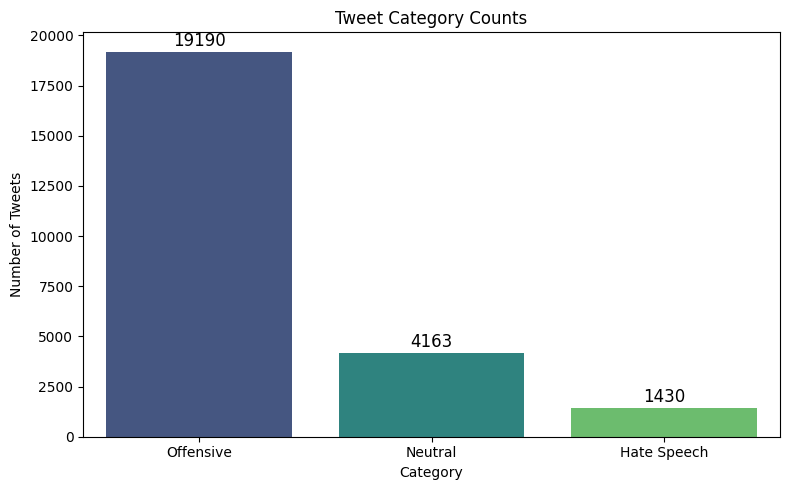

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map class labels for better readability
label_map = {0: "Hate Speech", 1: "Offensive", 2: "Neutral"}
df['class_label'] = df['class'].map(label_map)

# Count the values
count_series = df['class_label'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=count_series.index, y=count_series.values, palette='viridis')

# Annotate count values on top of bars
for i, count in enumerate(count_series.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=12)

plt.title("Tweet Category Counts")
plt.xlabel("Category")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()


In [30]:
from nltk.stem import WordNetLemmatizer
import re
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()  # Lowercase text
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'#\w+', '', text)  # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and digits
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in stopwords.words('english')])  # Lemmatization & remove stopwords
    return text


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [31]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['tweet']).toarray()
y = df['class']


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, accuracy_score


In [34]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\nModel: {model.__class__.__name__}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    return {
        'model': model.__class__.__name__,
        'accuracy': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }


In [17]:
results = []

# Naive Bayes
nb_model = MultinomialNB()
results.append(evaluate_model(nb_model, X_train, X_test, y_train, y_test))

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
results.append(evaluate_model(dt_model, X_train, X_test, y_train, y_test))

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
results.append(evaluate_model(rf_model, X_train, X_test, y_train, y_test))

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
results.append(evaluate_model(lr_model, X_train, X_test, y_train, y_test))



Model: MultinomialNB
Accuracy: 0.832963485979423
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       290
           1       0.83      0.99      0.90      3832
           2       0.88      0.39      0.54       835

    accuracy                           0.83      4957
   macro avg       0.57      0.46      0.48      4957
weighted avg       0.79      0.83      0.79      4957



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m


Model: DecisionTreeClassifier
Accuracy: 0.8755295541658261
Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.23      0.27       290
           1       0.92      0.93      0.93      3832
           2       0.80      0.84      0.82       835

    accuracy                           0.88      4957
   macro avg       0.68      0.67      0.67      4957
weighted avg       0.87      0.88      0.87      4957


Model: RandomForestClassifier
Accuracy: 0.8882388541456526
Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.12      0.19       290
           1       0.92      0.95      0.94      3832
           2       0.80      0.85      0.82       835

    accuracy                           0.89      4957
   macro avg       0.72      0.64      0.65      4957
weighted avg       0.87      0.89      0.87      4957


Model: LogisticRegression
Accuracy: 0.8908614081097438
Classification

Best Model: Logistic Regression
Highest accuracy (0.891).

Strong macro F1-score (0.67).

Handles all classes reasonably, including hate speech (class 0), which others struggle with.

Great precision/recall balance across classes 1 and 2

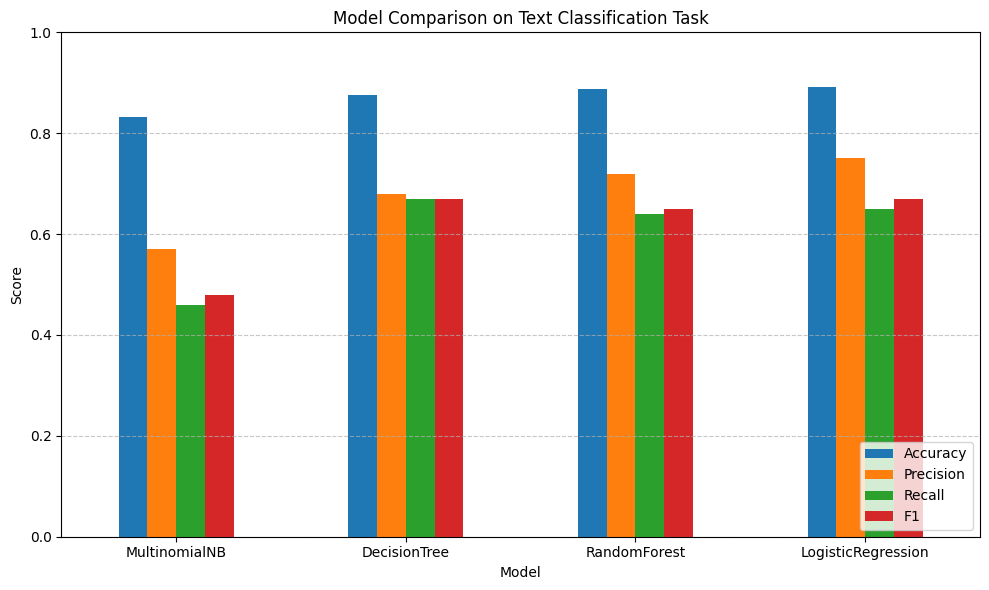

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Store your results here (update if exact values change)
model_results = [
    {"Model": "MultinomialNB", "Accuracy": 0.8329, "Precision": 0.57, "Recall": 0.46, "F1": 0.48},
    {"Model": "DecisionTree", "Accuracy": 0.8755, "Precision": 0.68, "Recall": 0.67, "F1": 0.67},
    {"Model": "RandomForest", "Accuracy": 0.8882, "Precision": 0.72, "Recall": 0.64, "F1": 0.65},
    {"Model": "LogisticRegression", "Accuracy": 0.8909, "Precision": 0.75, "Recall": 0.65, "F1": 0.67}
]

df_results = pd.DataFrame(model_results)

# Set model as index
df_results.set_index("Model", inplace=True)

# Plot
df_results.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison on Text Classification Task")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [35]:
# Final model (Random Forest)
final_rf_model = RandomForestClassifier(random_state=42)
final_rf_model.fit(X_train, y_train)

# Evaluate final model on test data
y_pred = final_rf_model.predict(X_test)
print(f"Final Model: {final_rf_model.__class__.__name__}")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Final Model: RandomForestClassifier
Accuracy: 0.8793625176518055
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.09      0.15       290
           1       0.89      0.97      0.93      3832
           2       0.85      0.73      0.78       835

    accuracy                           0.88      4957
   macro avg       0.76      0.59      0.62      4957
weighted avg       0.86      0.88      0.86      4957



In [50]:
# Saving the trained Random Forest model (if needed for later use)
import joblib
joblib.dump(final_rf_model, "final_rf_model.pkl")


['final_rf_model.pkl']

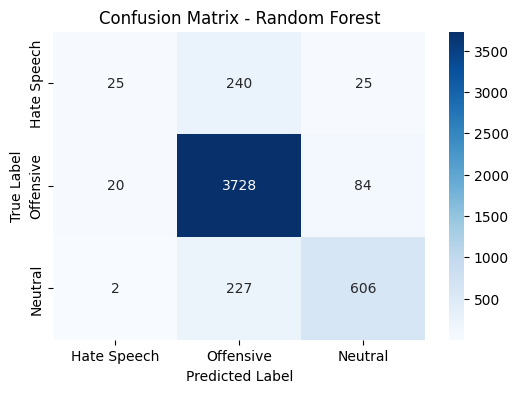

In [37]:
# Confusion matrix for the final model (Random Forest)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hate Speech', 'Offensive', 'Neutral'], yticklabels=['Hate Speech', 'Offensive', 'Neutral'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [47]:
# Initialize RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

In [48]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

# Assuming you already have your vectorizer fitted
tfidf = TfidfVectorizer(max_features=5000)

# Fit the vectorizer on your dataset
X = tfidf.fit_transform(df['tweet']).toarray()  # Assuming 'df['clean_tweet']' is your cleaned text data

# Save the vectorizer to a file
joblib.dump(tfidf, 'vectorizer.pkl')  # Saves the vectorizer in the current directory


['vectorizer.pkl']

In [51]:
import joblib

# Load the trained model
model = joblib.load("final_rf_model.pkl")  # Update with your model's file name if needed

# Load the vectorizer
vectorizer = joblib.load("vectorizer.pkl")  # Update with the correct path if needed


In [52]:
# Function to predict the category of a tweet
def predict_category(text):
    # Clean the input text just like you did for your dataset
    cleaned_text = clean_text(text)  # Use the same clean_text function for user input

    # Vectorize the cleaned text using the loaded vectorizer
    text_vectorized = vectorizer.transform([cleaned_text])

    # Predict using the loaded model
    prediction = model.predict(text_vectorized)

    # Output the prediction result (you can map the result to the corresponding class label)
    if prediction == 0:
        return "Hate Speech"

    elif prediction == 1:
        return "Offensive"
    else:
        return "Neutral"

# Example usage
user_input = "This is a test tweet!"  # Replace with user input
predicted_category = predict_category(user_input)
print(f"Predicted Category: {predicted_category}")


Predicted Category: Neutral


In [53]:
user_input = "I hate all people from [country/region]. They should leave this place!"
predicted_category = predict_category(user_input)
print(f"Predicted Category: {predicted_category}")


Predicted Category: Hate Speech


In [54]:
user_input = "You're so dumb, nobody wants to hear your stupid opinion."
predicted_category = predict_category(user_input)
print(f"Predicted Category: {predicted_category}")


Predicted Category: Offensive
